In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [2]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

seaborn   : 0.13.2
tensorflow: 2.19.0
matplotlib: 3.9.2
sklearn   : 1.5.1
plotly    : 5.24.1
numpy     : 1.26.4
keras     : 3.10.0
pandas    : 2.2.2



In [3]:
sns.set_style('darkgrid')

In [4]:
data = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Series_Temporais_isp/BaseDPEvolucaoMensalCisp.csv', encoding='latin-1', sep=';')
ultimos_dados = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Series_Temporais_isp/BaseDPEvolucaoMensalCisp_novo.csv', encoding='latin-1', sep=';')


In [5]:
df = data[['mes_ano', 'registro_ocorrencias']]

In [6]:
df['mes_ano'] = df['mes_ano'].str.replace('m', '/')
df['mes_ano'] = pd.to_datetime(df['mes_ano'], format='%Y/%m')

In [7]:
df = df.groupby('mes_ano', as_index=False)['registro_ocorrencias'].sum()

In [8]:
df = df.set_index('mes_ano')

In [33]:
df.head()

,registro_ocorrencias
mes_ano,
2003-01-01,44793
2003-02-01,45403
2003-03-01,45417
2003-04-01,44184
2003-05-01,45572


In [32]:
df['registro_ocorrencias'].astype('float32')

mes_ano
2003-01-01    44793.0
2003-02-01    45403.0
2003-03-01    45417.0
2003-04-01    44184.0
2003-05-01    45572.0
               ...   
2024-12-01    76987.0
2025-01-01    81562.0
2025-02-01    80306.0
2025-03-01    84129.0
2025-04-01    75761.0
Name: registro_ocorrencias, Length: 268, dtype: float32

In [10]:
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size

In [11]:
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)]

In [12]:
scaler_target = MinMaxScaler()

In [13]:
train['registro_ocorrencias'] = scaler_target.fit_transform(train['registro_ocorrencias'].to_numpy().reshape(-1, 1))

In [14]:
test['registro_ocorrencias'] = scaler_target.transform(test[['registro_ocorrencias']])

In [15]:
def createDataset(X, y, time_steps):
    
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)        
        ys.append(y.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

In [16]:
time_steps = 3

In [17]:
X_train, y_train = createDataset(train, train.registro_ocorrencias, time_steps)

In [18]:
X_test, y_test = createDataset(test, test.registro_ocorrencias, time_steps)

In [19]:
modelo_gru = tf.keras.Sequential()
modelo_gru.add(tf.keras.layers.GRU(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_gru.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_gru.add(tf.keras.layers.Dense(units = 1))

In [20]:
modelo_gru.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [21]:
modelo_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,433 (197.00 KB)

 Trainable params: 50,433 (197.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
%%time
modelo_gru_history = modelo_gru.fit(X_train, 
                                    y_train,
                                    epochs = 100,
                                    batch_size = 32,
                                    validation_split = 0.1,
                                    shuffle = False)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.1998 - val_loss: 0.1405
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0371 - val_loss: 0.0373
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0081 - val_loss: 0.0598
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0343 - val_loss: 0.0507
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0212 - val_loss: 0.0352
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0105 - val_loss: 0.0358
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0081 - val_loss: 0.0351
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0079 - val_loss: 0.0344
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0084 - val_loss: 0.0358
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0102 - val_loss: 0.0357
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0101 - val_loss: 0.0348
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0079 - val_lo

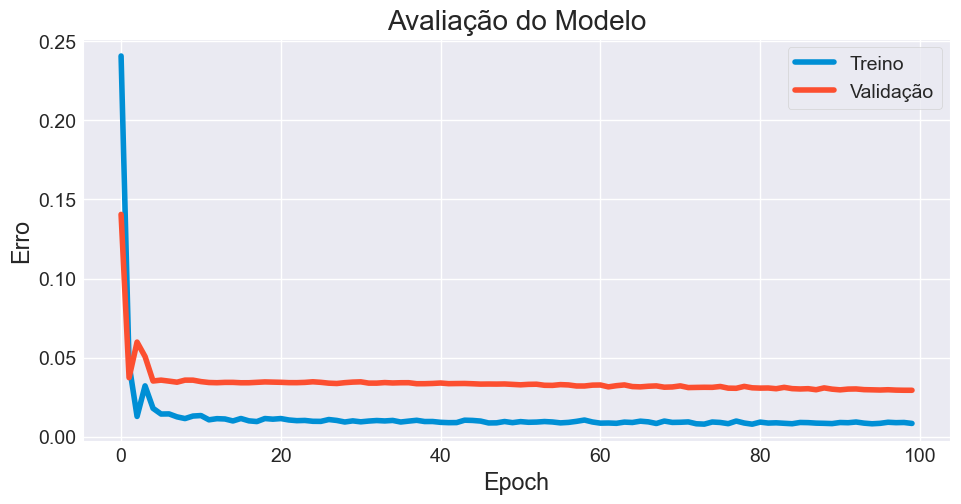

In [23]:
plt.plot(modelo_gru_history.history['loss'])
plt.plot(modelo_gru_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [24]:
y_pred = modelo_gru.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


In [25]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1)).flatten()
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1)).flatten()
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1)).flatten()

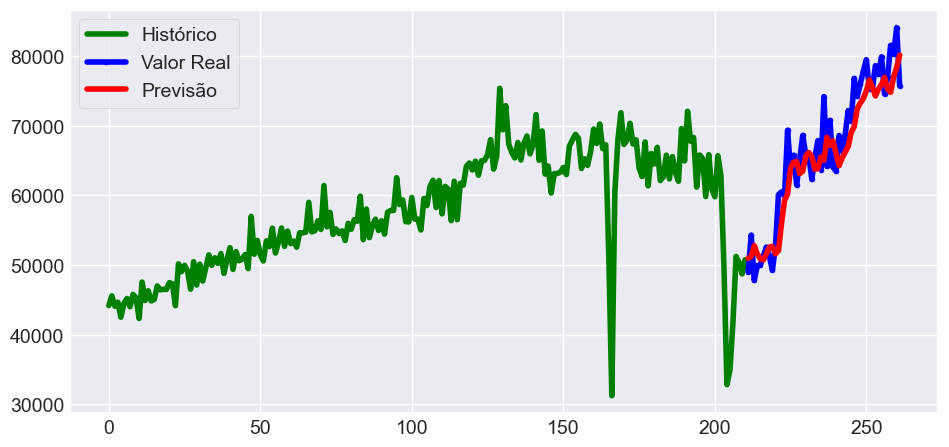

In [26]:
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.legend()
plt.show();

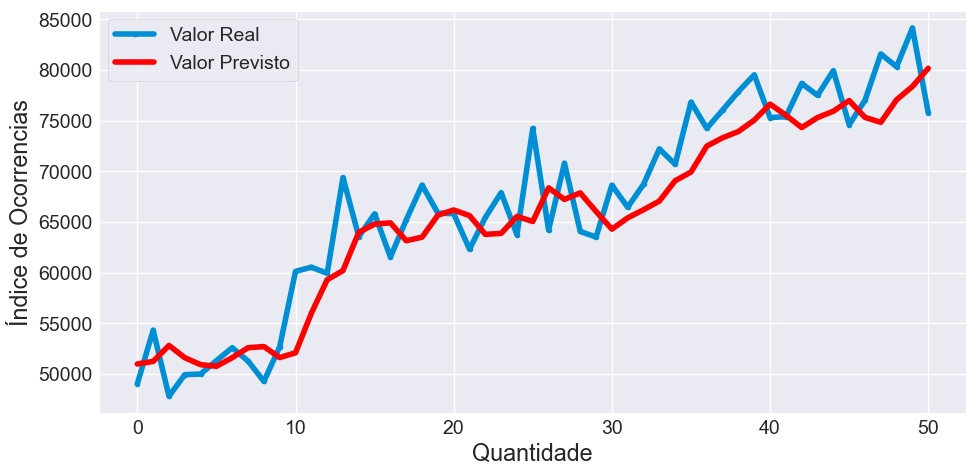

In [27]:
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Índice de Ocorrencias')
plt.xlabel('Quantidade')
plt.legend()
plt.show();

In [28]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [29]:
MDA_gru = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_gru)

MAE_gru = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_gru)

MSE_gru = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_gru)

RMSE_gru = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_gru)

EVS_gru = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_gru)

MDA: 0.36
MAE: 3132.5238204656866
MSE: 14657978.921626378
RMSE: 3828.5740062882915
EVS Score: 0.8725764396299077


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Previsão para o próximo mês: 77568


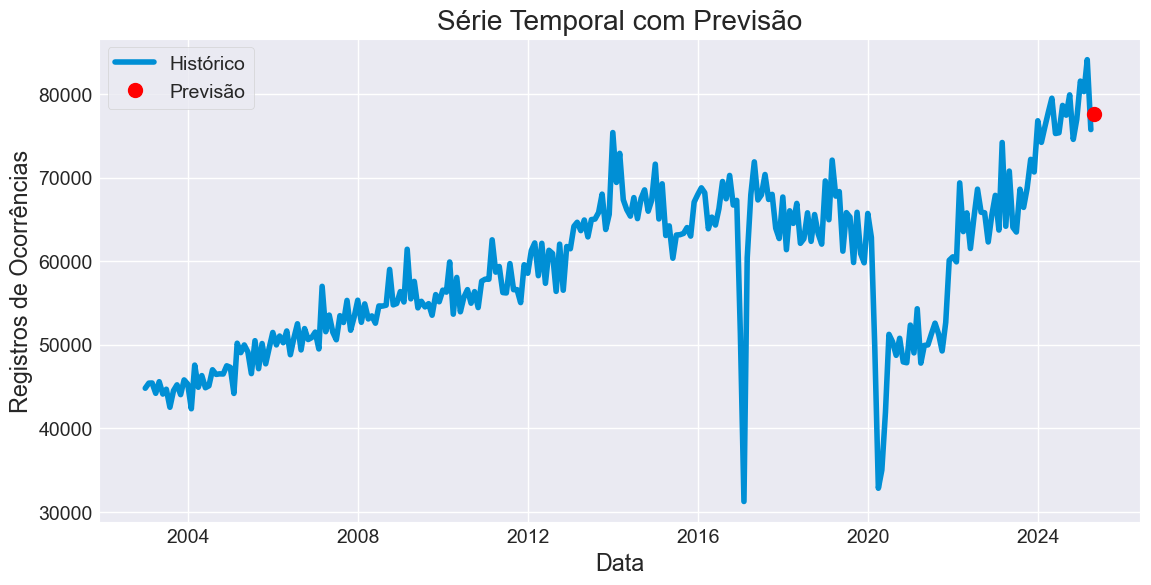

In [30]:
ultimos_dados = df['registro_ocorrencias'].iloc[-3:].values
ultimos_dados = ultimos_dados.reshape(1, 3, 1)  

ultimos_dados_norm = scaler_target.transform(ultimos_dados.reshape(-1, 1)).reshape(1, 3, 1)

proxima_previsao = modelo_gru.predict(ultimos_dados_norm)

proxima_previsao_inv = scaler_target.inverse_transform(proxima_previsao)

print("Previsão para o próximo mês:", int(proxima_previsao_inv[0][0]))

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['registro_ocorrencias'], label='Histórico')
plt.plot(df.index[-1] + pd.DateOffset(months=1), proxima_previsao_inv[0][0], 
         'ro', label='Previsão', markersize=10)
plt.title('Série Temporal com Previsão')
plt.xlabel('Data')
plt.ylabel('Registros de Ocorrências')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


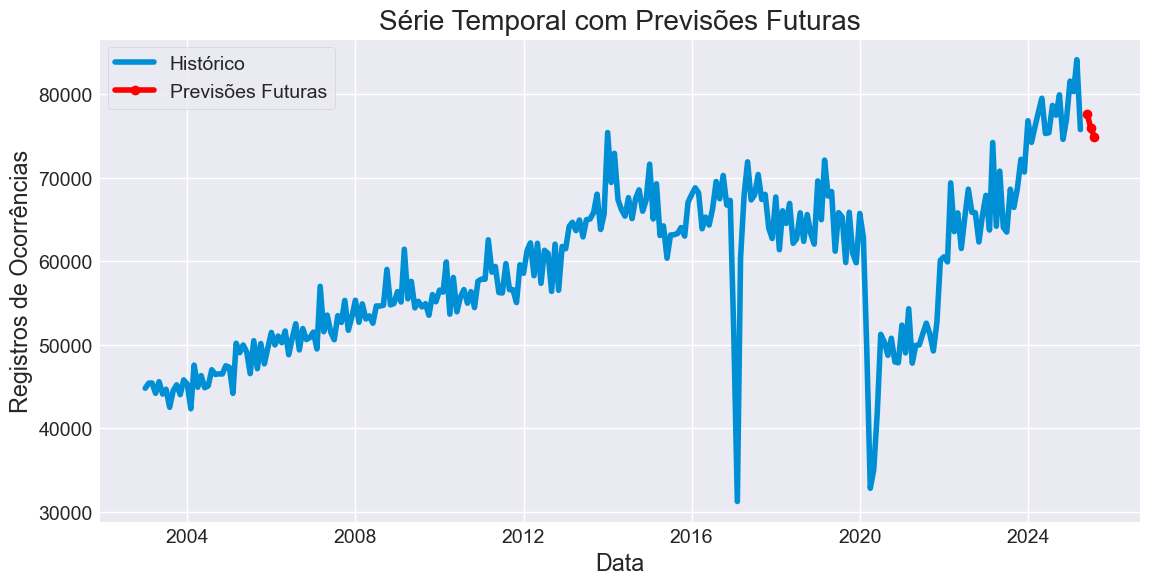

Previsão para 2025-05: 77568
Previsão para 2025-06: 75949
Previsão para 2025-07: 74910


In [31]:
n_meses = 3
previsoes_futuras = []
dados_entrada = ultimos_dados_norm.copy()

for _ in range(n_meses):

    prox_previsao = modelo_gru.predict(dados_entrada)
    previsoes_futuras.append(prox_previsao[0][0])
    
    dados_entrada = np.roll(dados_entrada, -1)
    dados_entrada[0][-1] = prox_previsao

previsoes_futuras = scaler_target.inverse_transform(np.array(previsoes_futuras).reshape(-1, 1))

ultimas_datas = pd.date_range(start=df.index[-1], periods=n_meses+1, freq='M')[1:]

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['registro_ocorrencias'], label='Histórico')
plt.plot(ultimas_datas, previsoes_futuras, 'ro-', label='Previsões Futuras')
plt.title('Série Temporal com Previsões Futuras')
plt.xlabel('Data')
plt.ylabel('Registros de Ocorrências')
plt.legend()
plt.grid(True)
plt.show()

for data, previsao in zip(ultimas_datas, previsoes_futuras):
    print(f"Previsão para {data.strftime('%Y-%m')}: {int(previsao[0])}")